# Selecting Multiple Landsat Images for Para, Brazil

In [38]:
from pystac_client import Client
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import rioxarray as rxr

## Exploring Element 84's Earth Science Catalogue
### Connecting to the API

In [2]:
client = Client.open('https://earth-search.aws.element84.com/v1')

### Printing Collection Names

In [3]:
collections = client.get_collections()

for i in collections:
    print(i.id)

sentinel-2-pre-c1-l2a
cop-dem-glo-30
naip
cop-dem-glo-90
landsat-c2-l2
sentinel-2-l2a
sentinel-2-l1c
sentinel-2-c1-l2a
sentinel-1-grd


## Creating the Para Geometry
### Inspecting the Para GeoDataFrame

In [4]:
para = gpd.read_file('../data/vectors/para.gpkg')
para.shape

(1, 8)

In [5]:
print(para.crs)

EPSG:4674


In [6]:
para = para.to_crs('EPSG:4326')
para.head(1)

,CD_UF,NM_UF,SIGLA_UF,CD_REGIA,NM_REGIA,SIGLA_RG,AREA_KM2,geometry
0,15,Pará,PA,1,Norte,N,1245828.829,"MULTIPOLYGON (((-50.84599 -9.80064, -51.05801 ..."


### Creating the Para Extents Geometry

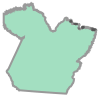

In [7]:
para_geom = para['geometry'].iloc[0]
para_geom

## Retrieving Landsat Data
### Creating the Search Query

In [8]:
search = client.search(
    collections=['landsat-c2-l2'],
    intersects=para_geom,
    datetime='2024-01-01/2024-12-31',
)
items = list(search.items())

print(f'Found {len(items)} items')

Found 3287 items


### Creating a GeoDataFrame

In [25]:
total_ids = gpd.GeoDataFrame.from_features(items, crs='EPSG:4326')
total_ids.shape

(3287, 29)

In [46]:
total_ids.iloc[0]['landsat:collection_number']

'02'

In [44]:
total_ids.columns

Index(['geometry', 'platform', 'instruments', 'created', 'gsd', 'description',
       'eo:cloud_cover', 'view:off_nadir', 'view:sun_elevation',
       'view:sun_azimuth', 'proj:shape', 'proj:transform', 'proj:centroid',
       'landsat:cloud_cover_land', 'landsat:wrs_type', 'landsat:wrs_path',
       'landsat:wrs_row', 'landsat:collection_category',
       'landsat:collection_number', 'landsat:correction', 'landsat:scene_id',
       'landsat:product_generated', 'grid:code', 'sci:doi', 'datetime',
       'earthsearch:payload_id', 'processing:software', 'updated', 'proj:code',
       'id'],
      dtype='object')

In [26]:
total_ids['id'] = [item.id for item in items]
total_ids.head(1)

,geometry,platform,instruments,created,gsd,description,eo:cloud_cover,view:off_nadir,view:sun_elevation,view:sun_azimuth,...,landsat:scene_id,landsat:product_generated,grid:code,sci:doi,datetime,earthsearch:payload_id,processing:software,updated,proj:code,id
0,"POLYGON ((-51.93531 -9.08177, -52.31617 -10.81...",landsat-9,"[oli, tirs]",2025-01-02T02:42:32.617Z,30,Landsat Collection 2 Level-2,90.61,0,59.309376,118.55105,...,LC92240672024366LGN00,2025-01-02T02:00:17Z,WRS2-224067,10.5066/P9OGBGM6,2024-12-31T13:31:47.413259Z,usgs-landsat-c2l2/workflow-landsat-to-stac/bef...,{'landsat-to-stac': 'v2023.11.16'},2025-01-02T02:42:32.617Z,EPSG:32622,LC09_L2SP_224067_20241231_02_T2


### Typecasting the DateTime Column

In [27]:
total_ids['datetime'] = pd.to_datetime(total_ids['datetime'])

### Filtering by Cloud Cover

In [28]:
lowest_cloud = total_ids.sort_values('eo:cloud_cover').groupby('grid:code', as_index=False).head(1)
lowest_cloud

,geometry,platform,instruments,created,gsd,description,eo:cloud_cover,view:off_nadir,view:sun_elevation,view:sun_azimuth,...,landsat:scene_id,landsat:product_generated,grid:code,sci:doi,datetime,earthsearch:payload_id,processing:software,updated,proj:code,id
1705,"POLYGON ((-56.26758 -7.63463, -56.64623 -9.367...",landsat-8,"[oli, tirs]",2024-07-06T05:16:07.711Z,30,Landsat Collection 2 Level-2,0.00,0,47.324886,40.622804,...,LC82270662024171LGN00,2024-07-06T04:31:42Z,WRS2-227066,10.5066/P9OGBGM6,2024-06-19 13:49:00.686491+00:00,usgs-landsat-c2l2/workflow-landsat-to-stac/e86...,{'landsat-to-stac': 'v2023.11.16'},2024-07-06T05:16:07.711Z,EPSG:32621,LC08_L2SP_227066_20240619_02_T1
1643,"POLYGON ((-58.13238 -9.07986, -58.51371 -10.81...",landsat-8,"[oli, tirs]",2024-07-09T05:04:37.228Z,30,Landsat Collection 2 Level-2,0.00,0,45.935938,40.283834,...,LC82280672024178LGN00,2024-07-09T04:30:07Z,WRS2-228067,10.5066/P9OGBGM6,2024-06-26 13:55:40.147544+00:00,usgs-landsat-c2l2/workflow-landsat-to-stac/f0e...,{'landsat-to-stac': 'v2023.11.16'},2024-07-09T05:04:37.228Z,EPSG:32621,LC08_L2SP_228067_20240626_02_T1
3236,"POLYGON ((-59.42497 -6.30609, -59.76603 -7.924...",landsat-7,[etm+],2024-01-30T12:51:33.881Z,30,Landsat Collection 2 Level-2,0.00,0,24.103675,111.719781,...,LE72290652024004ASN00,2024-01-30T12:20:25Z,WRS2-229065,10.5066/P9C7I13B,2024-01-04 11:32:14.123868+00:00,usgs-landsat-c2l2/workflow-landsat-to-stac/5df...,{'landsat-to-stac': 'v2023.11.16'},2024-01-30T12:51:33.881Z,EPSG:32621,LE07_L2SP_229065_20240104_02_T2
1171,"POLYGON ((-59.37004 -0.40637, -59.74006 -2.141...",landsat-9,"[oli, tirs]",2024-08-20T12:23:19.354Z,30,Landsat Collection 2 Level-2,0.00,0,58.820384,62.649715,...,LC92300612024232LGN00,2024-08-20T11:55:24Z,WRS2-230061,10.5066/P9OGBGM6,2024-08-19 14:06:02.892038+00:00,usgs-landsat-c2l2/workflow-landsat-to-stac/634...,{'landsat-to-stac': 'v2023.11.16'},2024-08-20T12:23:19.354Z,EPSG:32621,LC09_L2SP_230061_20240819_02_T1
1761,"POLYGON ((-52.24621 -3.29923, -52.61717 -5.033...",landsat-9,"[oli, tirs]",2024-06-14T11:52:09.383Z,30,Landsat Collection 2 Level-2,0.00,0,51.316810,43.255314,...,LC92250632024165LGN00,2024-06-14T11:15:37Z,WRS2-225063,10.5066/P9OGBGM6,2024-06-13 13:35:30.881691+00:00,usgs-landsat-c2l2/workflow-landsat-to-stac/5e1...,{'landsat-to-stac': 'v2023.11.16'},2024-06-14T11:52:09.383Z,EPSG:32622,LC09_L2SP_225063_20240613_02_T1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1525,"POLYGON ((-47.95583 -4.74462, -48.33033 -6.478...",landsat-9,"[oli, tirs]",2024-07-11T12:24:47.973Z,30,Landsat Collection 2 Level-2,8.33,0,49.962621,44.843404,...,LC92220642024192LGN00,2024-07-11T12:00:58Z,WRS2-222064,10.5066/P9OGBGM6,2024-07-10 13:17:29.632890+00:00,usgs-landsat-c2l2/workflow-landsat-to-stac/702...,{'landsat-to-stac': 'v2023.11.16'},2024-07-11T12:24:47.973Z,EPSG:32623,LC09_L2SP_222064_20240710_02_T1
1134,"POLYGON ((-51.01354 2.48849, -51.3821 0.75331,...",landsat-8,"[oli, tirs]",2024-08-31T01:55:40.278Z,30,Landsat Collection 2 Level-2,11.50,0,61.297516,69.850342,...,LC82250592024237LGN00,2024-08-31T01:34:42Z,WRS2-225059,10.5066/P9OGBGM6,2024-08-24 13:34:25.153919+00:00,usgs-landsat-c2l2/workflow-landsat-to-stac/2f2...,{'landsat-to-stac': 'v2023.11.16'},2024-08-31T01:55:40.278Z,EPSG:32622,LC08_L2SP_225059_20240824_02_T1
1133,"POLYGON ((-51.32065 1.04237, -51.68999 -0.6927...",landsat-8,"[oli, tirs]",2024-08-31T01:55:21.417Z,30,Landsat Collection 2 Level-2,12.70,0,60.578511,67.558443,...,LC82250602024237LGN00,2024-08-31T01:28:43Z,WRS2-225060,10.5066/P9OGBGM6,2024-08-24 13:34:49.070376+00:00,usgs-landsat-c2l2/workflow-landsat-to-stac/9b9...,{'landsat-to-stac': 'v2023.11.16'},2024-08-31T01:55:21.417Z,EPSG:32622,LC08_L2SP_225060_20240824_02_T1
3171,"POLYGON ((-60.1613 -6.30377, -60.50174 -7.9217...",landsat-7,[etm+],2024-02-04T11:51:31.338Z,30,Landsat Collection 2 Level-2,62.00,0,23.472877,111.031084,...,LE72300652024009ASN00,2024-02-04T11:14:21Z,WRS2-230065,10.5066/P9C7I13B,2024-

### Accessing Value Counts for the Cloud Cover Column

In [29]:
lowest_cloud['eo:cloud_cover'].value_counts()

eo:cloud_cover
0.00     39
0.01      2
0.03      2
0.07      2
0.02      1
0.04      1
0.05      1
0.13      1
0.18      1
0.21      1
0.32      1
0.46      1
0.49      1
0.57      1
0.66      1
0.74      1
0.93      1
1.04      1
1.30      1
1.53      1
1.61      1
1.63      1
1.74      1
2.97      1
4.47      1
5.00      1
5.48      1
6.02      1
8.33      1
11.50     1
12.70     1
62.00     1
81.00     1
Name: count, dtype: int64

### Visualising the Spatial Extent of Selected Items

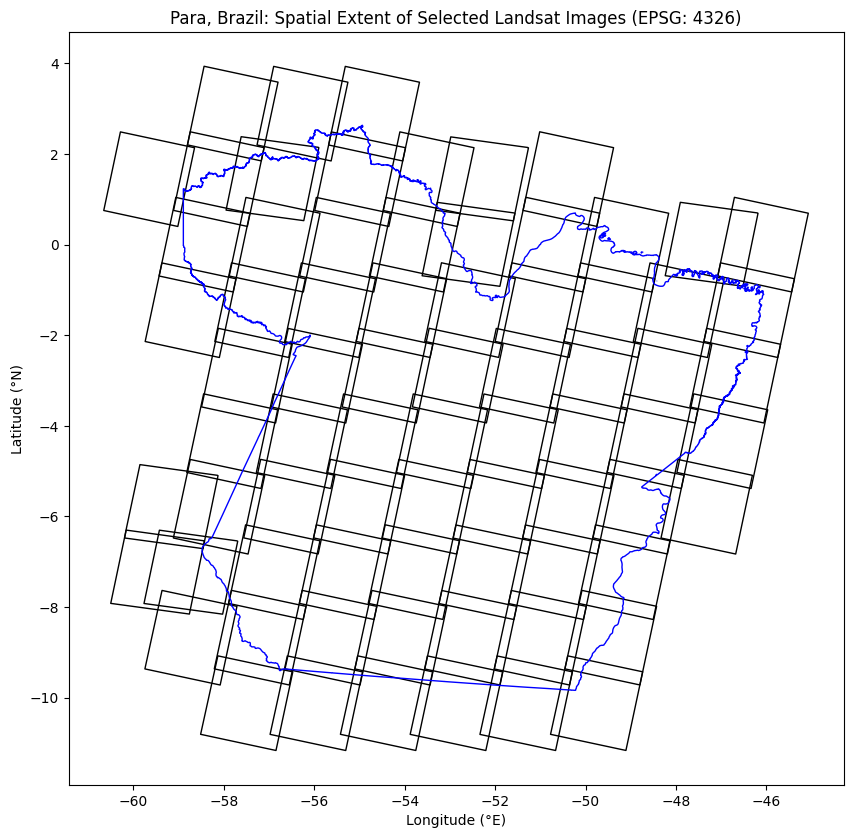

In [30]:
fig, ax = plt.subplots(figsize=(10,10))

lowest_cloud.plot(ax=ax, color='none')
para.plot(ax=ax, color='none', edgecolor='blue')

ax.set_title('Para, Brazil: Spatial Extent of Selected Landsat Images (EPSG: 4326)')
ax.set_xlabel('Longitude (°E)')
ax.set_ylabel('Latitude (°N)')

plt.show()

In [31]:
lowest_cloud.explore()

## Selecting the Chosen Items
### Creating a Dictionary of Chosen Items

In [32]:
item_dict = {item.id: item for item in items}

### Mapping the Dictionary to the Lowest Cloud GeoDataFrame

In [33]:
lowest_cloud['item'] = lowest_cloud['id'].map(item_dict)
lowest_cloud.head()

,geometry,platform,instruments,created,gsd,description,eo:cloud_cover,view:off_nadir,view:sun_elevation,view:sun_azimuth,...,landsat:product_generated,grid:code,sci:doi,datetime,earthsearch:payload_id,processing:software,updated,proj:code,id,item
1705,"POLYGON ((-56.26758 -7.63463, -56.64623 -9.367...",landsat-8,"[oli, tirs]",2024-07-06T05:16:07.711Z,30,Landsat Collection 2 Level-2,0.0,0,47.324886,40.622804,...,2024-07-06T04:31:42Z,WRS2-227066,10.5066/P9OGBGM6,2024-06-19 13:49:00.686491+00:00,usgs-landsat-c2l2/workflow-landsat-to-stac/e86...,{'landsat-to-stac': 'v2023.11.16'},2024-07-06T05:16:07.711Z,EPSG:32621,LC08_L2SP_227066_20240619_02_T1,<Item id=LC08_L2SP_227066_20240619_02_T1>
1643,"POLYGON ((-58.13238 -9.07986, -58.51371 -10.81...",landsat-8,"[oli, tirs]",2024-07-09T05:04:37.228Z,30,Landsat Collection 2 Level-2,0.0,0,45.935938,40.283834,...,2024-07-09T04:30:07Z,WRS2-228067,10.5066/P9OGBGM6,2024-06-26 13:55:40.147544+00:00,usgs-landsat-c2l2/workflow-landsat-to-stac/f0e...,{'landsat-to-stac': 'v2023.11.16'},2024-07-09T05:04:37.228Z,EPSG:32621,LC08_L2SP_228067_20240626_02_T1,<Item id=LC08_L2SP_228067_20240626_02_T1>
3236,"POLYGON ((-59.42497 -6.30609, -59.76603 -7.924...",landsat-7,[etm+],2024-01-30T12:51:33.881Z,30,Landsat Collection 2 Level-2,0.0,0,24.103675,111.719781,...,2024-01-30T12:20:25Z,WRS2-229065,10.5066/P9C7I13B,2024-01-04 11:32:14.123868+00:00,usgs-landsat-c2l2/workflow-landsat-to-stac/5df...,{'landsat-to-stac': 'v2023.11.16'},2024-01-30T12:51:33.881Z,EPSG:32621,LE07_L2SP_229065_20240104_02_T2,<Item id=LE07_L2SP_229065_20240104_02_T2>
1171,"POLYGON ((-59.37004 -0.40637, -59.74006 -2.141...",landsat-9,"[oli, tirs]",2024-08-20T12:23:19.354Z,30,Landsat Collection 2 Level-2,0.0,0,58.820384,62.649715,...,2024-08-20T11:55:24Z,WRS2-230061,10.5066/P9OGBGM6,2024-08-19 14:06:02.892038+00:00,usgs-landsat-c2l2/workflow-landsat-to-stac/634...,{'landsat-to-stac': 'v2023.11.16'},2024-08-20T12:23:19.354Z,EPSG:32621,LC09_L2SP_230061_20240819_02_T1,<Item id=LC09_L2SP_230061_20240819_02_T1>
1761,"POLYGON ((-52.24621 -3.29923, -52.61717 -5.033...",landsat-9,"[oli, tirs]",2024-06-14T11:52:09.383Z,30,Landsat Collection 2 Level-2,0.0,0,51.316810,43.255314,...,2024-06-14T11:15:37Z,WRS2-225063,10.5066/P9OGBGM6,2024-06-13 13:35:30.881691+00:00,usgs-landsat-c2l2/workflow-landsat-to-stac/5e1...,{'landsat-to-stac': 'v2023.11.16'},2024-06-14T11:52:09.383Z,EPSG:32622,LC09_L2SP_225063_20240613_02_T1,<Item id=LC09_L2SP_225063_20240613_02_T1>


## Creating RGB Composites
### Selecting the First Item

In [34]:
item = lowest_cloud['item'].iloc[0]

In [43]:
item

<Item id=LC08_L2SP_227066_20240619_02_T1>

In [36]:
assets = item.assets
assets

{'thumbnail': <Asset href=s3://usgs-landsat/collection02/level-2/standard/oli-tirs/2024/227/066/LC08_L2SP_227066_20240619_20240706_02_T1/LC08_L2SP_227066_20240619_20240706_02_T1_thumb_small.jpeg>,
 'reduced_resolution_browse': <Asset href=s3://usgs-landsat/collection02/level-2/standard/oli-tirs/2024/227/066/LC08_L2SP_227066_20240619_20240706_02_T1/LC08_L2SP_227066_20240619_20240706_02_T1_thumb_large.jpeg>,
 'mtl.json': <Asset href=s3://usgs-landsat/collection02/level-2/standard/oli-tirs/2024/227/066/LC08_L2SP_227066_20240619_20240706_02_T1/LC08_L2SP_227066_20240619_20240706_02_T1_MTL.json>,
 'mtl.txt': <Asset href=s3://usgs-landsat/collection02/level-2/standard/oli-tirs/2024/227/066/LC08_L2SP_227066_20240619_20240706_02_T1/LC08_L2SP_227066_20240619_20240706_02_T1_MTL.txt>,
 'mtl.xml': <Asset href=s3://usgs-landsat/collection02/level-2/standard/oli-tirs/2024/227/066/LC08_L2SP_227066_20240619_20240706_02_T1/LC08_L2SP_227066_20240619_20240706_02_T1_MTL.xml>,
 'ang': <Asset href=s3://usgs-

In [41]:
red = rxr.open_rasterio(assets['nir08'].href).squeeze('band', drop=True)

RasterioIOError: AWS_SECRET_ACCESS_KEY and AWS_NO_SIGN_REQUEST configuration options not defined, and /home/lorem/.aws/credentials not filled